In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import healpy as hp
import astropy.io.fits as fits
from matplotlib import cm
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import matplotlib.colors as mcolors

In [4]:
# rgb rendering of 'Planck color table 1'
my_rgb = np.loadtxt('planck_colors1_rgb.txt')
vals = np.ones((256, 4))
vals[:, 0] = my_rgb[:,0]/256.
vals[:, 1] = my_rgb[:,1]/256.
vals[:, 2] = my_rgb[:,2]/256.
newcmp = ListedColormap(vals)

In [5]:
# Input cleaned maps from initial cleaning fit
initial_70_map="INITIAL_Maps/Initial_Cleaned_70GHz.fits"
initial_70=hp.fitsfunc.read_map(initial_70_map,field=[0])

initial_94_map="INITIAL_Maps/Initial_Cleaned_94GHz.fits"
initial_94=hp.fitsfunc.read_map(initial_94_map,field=[0])

initial_100_map="INITIAL_Maps/Initial_Cleaned_100GHz.fits"
initial_100=hp.fitsfunc.read_map(initial_100_map,field=[0])

initial_143_map="INITIAL_Maps/Initial_Cleaned_143GHz.fits"
initial_143=hp.fitsfunc.read_map(initial_143_map,field=[0])

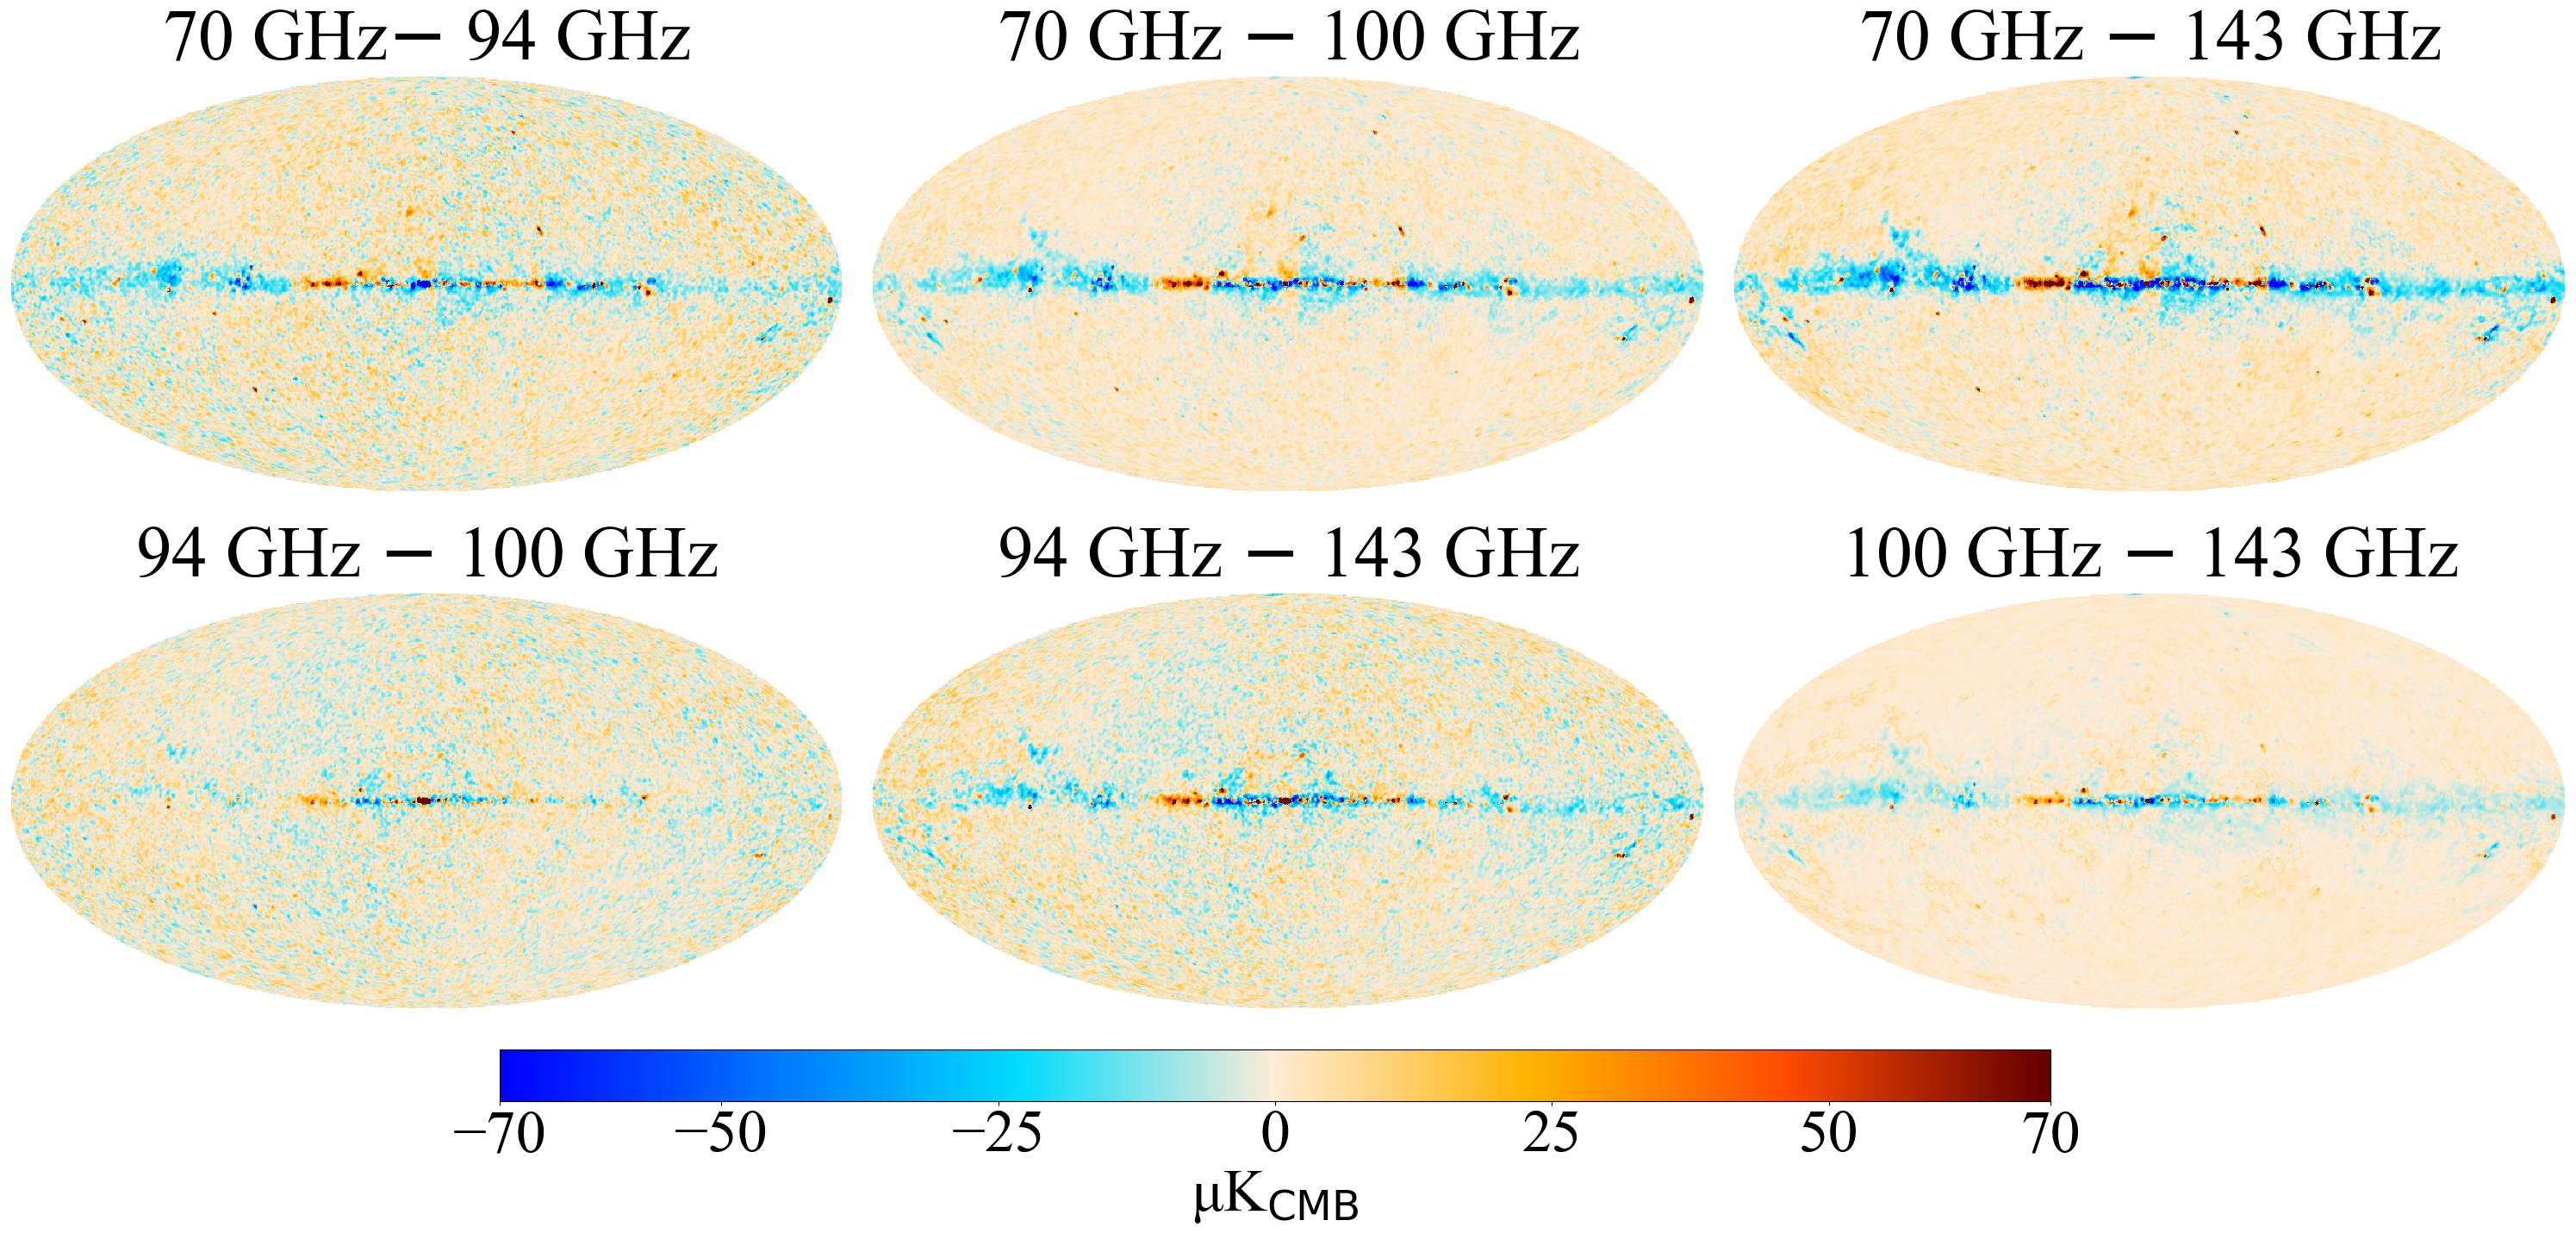

In [9]:
figsize = (30, 12)
fig = plt.figure(figsize=figsize)
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams.update({'font.size': 50})  

hp.mollview((initial_70-initial_94)*1000, min=-70, max=70, cmap=newcmp, sub=231, title='70 GHz$-$ 94 GHz', cbar=False,badcolor='black')
hp.mollview((initial_70-initial_100)*1000, min=-70, max=70, cmap=newcmp, sub=232, title='70 GHz $-$ 100 GHz', cbar=False,badcolor='black')
hp.mollview((initial_70-initial_143)*1000, min=-70, max=70, cmap=newcmp, sub=233, title='70 GHz $-$ 143 GHz', cbar=False,badcolor='black')
hp.mollview((initial_94-initial_100)*1000, min=-70, max=70, cmap=newcmp, sub=234, title='94 GHz $-$ 100 GHz', cbar=False,badcolor='black')
hp.mollview((initial_94-initial_143)*1000, min=-70, max=70, cmap=newcmp, sub=235, title='94 GHz $-$ 143 GHz', cbar=False,badcolor='black')
hp.mollview((initial_100-initial_143)*1000, min=-70, max=70, cmap=newcmp, sub=236, title='100 GHz $-$ 143 GHz', cbar=False,badcolor='black')

cbar_ax = fig.add_axes([0.2, -0.05, 0.6, 0.05])  
norm = mcolors.Normalize(vmin=-70, vmax=70)
sm = cm.ScalarMappable(cmap=newcmp, norm=norm)
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_ticks([-70, -50, -25, 0, 25, 50, 70])
cbar.set_label(r'μK$_{\rm CMB}$')  